# 01 — Marketplace Integrity Walkthrough

**Module:** `msmt.integrity` &nbsp;•&nbsp; **Companion to:** *Main Street Marketplace*, Article 1 — *What Marketplaces Actually Reward*.

This notebook walks an SBDC counselor through the toolkit's view of a small seller's *marketplace integrity* — the operational and content signals that, in aggregate, predict whether the marketplace's ranking and Buy-Box logic will reward or penalize the seller.

Two sections:

1. **Seller scorecard** — score one seller against ten signals across fulfillment, post-purchase, and content quality.
2. **Catalog concentration** — measure how exposed a seller is to single-SKU outage risk using the Herfindahl-Hirschman Index (HHI), the same statistic the U.S. Department of Justice uses for merger review.

> **Note on the data.** All inputs in this notebook are **synthetic**. The scorecard weights and benchmarks are practitioner estimates derived from publicly available platform guidance — they are not platform-disclosed algorithmic weights.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from msmt.data import generate_seller_data
from msmt.integrity import (
    SIGNALS, compute_scorecard, scorecard_for_synthetic_seller,
    hhi_per_category, concentration_audit,
)


# Section 1 — Seller scorecard

Ten signals, three groups, weights that sum to 100%:

| Group | Weight | Signals |
|---|---|---|
| Fulfillment | 40% | on-time shipment, valid tracking, pre-fulfillment cancels, late dispatch |
| Post-purchase | 35% | return rate, order defect rate, customer feedback |
| Content | 25% | listing-quality score, image count, keyword coverage |

Each signal is scored 0–100 by linear interpolation between a 'poor' and a 'good' benchmark. The overall scorecard is the weighted average. An overall score below 50 is flagged as **high** suppression risk; 50–75 is **medium**; 75+ is **low**.

### Pick a representative seller

We construct a synthetic seller with mixed signal quality — some good, some borderline, a couple weak — so the scorecard has interesting things to flag. A real seller would supply their own metrics from their seller-portal performance dashboard.

In [2]:
seller_metrics = {
    'on_time_shipment_rate':       0.94,   # borderline
    'valid_tracking_rate':         0.96,   # good
    'pre_fulfillment_cancel_rate': 0.03,   # fair
    'late_dispatch_rate':          0.06,   # poor
    'return_rate':                 0.18,   # poor
    'order_defect_rate':           0.012,  # fair
    'customer_feedback_score':     4.5,    # good
    'listing_quality_score':       72,     # fair
    'image_count':                 5,      # fair
    'keyword_coverage':            0.65,   # fair
}

scorecard = compute_scorecard(seller_metrics)
print(f"Overall score:    {scorecard['overall_score']:.1f} / 100")
print(f"Suppression risk: {scorecard['suppression_risk'].upper()}")


Overall score:    56.2 / 100
Suppression risk: MEDIUM


### Per-signal breakdown

Each row of this table is one signal: the value the seller reported, the 0–100 score the scorecard mapped it to, and the rating. A counselor uses this view to know exactly which levers to pull.

In [3]:
rows = []
for name, info in scorecard['signal_scores'].items():
    rows.append({
        'signal': name,
        'value': info['value'],
        'score (/100)': round(info['score_0_to_100'], 1),
        'rating': info['rating'],
        'weight': info['weight'],
    })
pd.DataFrame(rows).sort_values('score (/100)')


,signal,value,score (/100),rating,weight
3,late_dispatch_rate,0.060,0.0,poor,0.05
4,return_rate,0.180,0.0,poor,0.15
9,keyword_coverage,0.650,50.0,fair,0.05
0,on_time_shipment_rate,0.940,57.1,fair,0.15
7,listing_quality_score,72.000,60.0,fair,0.15
2,pre_fulfillment_cancel_rate,0.030,66.7,fair,0.10
8,image_count,5.000,66.7,fair,0.05
6,customer_feedback_score,4.500,71.4,fair,0.10
5,order_defect_rate,0.012,90.0,good,0.10
1,valid_tracking_rate,0.960,100.0,good,0.10


### Top issues + plain-English recommendations

The scorecard surfaces up to three signals with the lowest scores and pairs each with a recommendation written for a seller, not an engineer. This is the panel a counselor would walk through line by line.

In [4]:
for issue, rec in zip(scorecard['top_issues'], scorecard['recommendations']):
    print(f"\u2022 {issue['plain_english']}")
    print(f"  → {rec}")
    print()


• Late Dispatch Rate is poor (score 0/100).
  → Orders are dispatching late. Review handling-time settings on the listing and your warehouse cut-off times — most late dispatches are a same-day-cutoff calendar mistake, not a throughput problem.

• Return Rate is poor (score 0/100).
  → Your return rate is elevated. High returns signal listing-reality mismatch to the algorithm. Audit your top-returned SKUs for image accuracy and description completeness.

• Keyword Coverage is fair (score 50/100).
  → Listing is missing category-relevant keywords. Pull the category's top search terms and add the missing ones to the title, bullets, and back-end search fields.



### Chart 1 — signal scores by rating

Horizontal bar chart, color-coded by rating: green = good, yellow = fair, red = poor. The longer the bar, the better that signal is doing relative to the platform's typical thresholds.

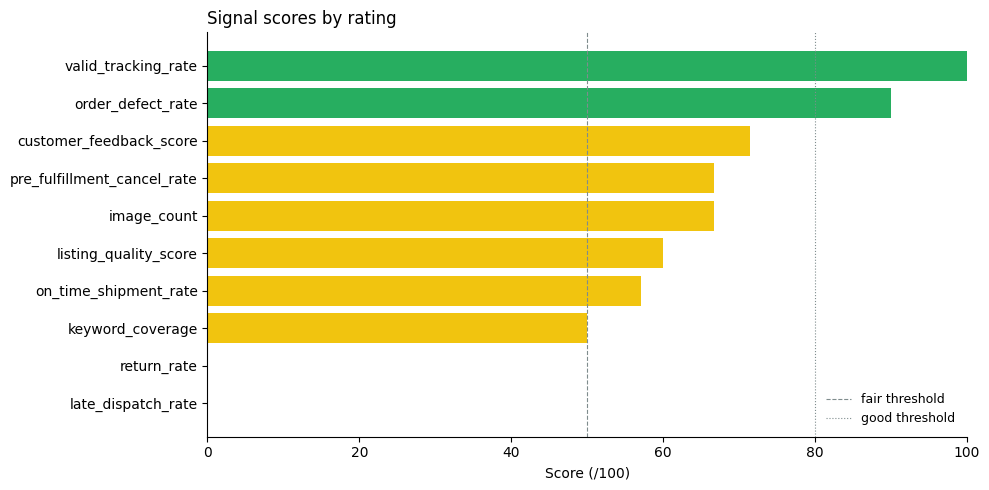

In [5]:
plt.style.use('default')
rating_colors = {'good': '#27ae60', 'fair': '#f1c40f', 'poor': '#c0392b'}
scores_df = pd.DataFrame([
    {'signal': k, 'score': v['score_0_to_100'], 'rating': v['rating']}
    for k, v in scorecard['signal_scores'].items()
]).sort_values('score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(scores_df['signal'], scores_df['score'],
        color=[rating_colors[r] for r in scores_df['rating']])
ax.axvline(50, color='#7f8c8d', linestyle='--', linewidth=0.8, label='fair threshold')
ax.axvline(80, color='#7f8c8d', linestyle=':', linewidth=0.8, label='good threshold')
ax.set_xlim(0, 100)
ax.set_xlabel('Score (/100)')
ax.set_title('Signal scores by rating', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


# Section 2 — Catalog concentration risk

The HHI tells a counselor whether a seller has put too many eggs in one basket within a given category. The DOJ uses three thresholds for merger review:

* **HHI < 1,500** — *low* concentration; volume is well distributed.
* **1,500 ≤ HHI ≤ 2,500** — *moderate*; watch list.
* **HHI > 2,500** — *high*; a single-SKU disruption could take the category offline.

The same logic applies to a small seller's catalog. If 90% of category volume rides on one SKU, an inventory hiccup or a listing suppression on that SKU is a category-level event.

In [6]:
catalog = generate_seller_data(n_skus=50, n_days=365, seed=42)
agg = catalog.groupby(['category', 'sku_id'])['units_sold'].sum().reset_index()
print(f'categories: {agg["category"].nunique()}  '
      f'SKUs: {agg["sku_id"].nunique()}  '
      f'rows: {len(agg)}')
agg.head()


categories: 8  SKUs: 50  rows: 50


,category,sku_id,units_sold
0,Arts & Crafts,SKU-HS-0032,3908
1,Arts & Crafts,SKU-HS-0034,3871
2,Arts & Crafts,SKU-IM-0042,186
3,Arts & Crafts,SKU-SM-0010,3528
4,Arts & Crafts,SKU-SM-0012,3590


In [7]:
audit = concentration_audit(agg)
summary = audit['summary_df']
summary.round(2)


,category,hhi,concentration_level,top_seller_share,seller_count
0,Office Products,4363.25,high,0.47,4
1,Pet Supplies,3338.98,high,0.36,4
2,Beauty & Personal Care,3132.81,high,0.37,5
3,Health & Household,3102.52,high,0.34,5
4,Home & Kitchen,1593.45,moderate,0.19,9
5,Outdoors,1441.21,low,0.16,7
6,Arts & Crafts,1422.44,low,0.16,8
7,Toys & Games,1417.03,low,0.16,8


### Audit narrative

Two or three plain-English sentences a state commerce program staffer can drop into a report:

In [8]:
print(audit['audit_narrative'])


Of 8 categories, 4 show high concentration (HHI > 2,500 — the DOJ threshold for "highly concentrated" markets in merger review): Office Products, Pet Supplies, Beauty & Personal Care, Health & Household. The average HHI across the catalog is 2,476. The seller is exposed to single-SKU outage risk in those categories and should consider diversifying volume across additional SKUs before scaling.


### Chart 2 — HHI by category

Bar chart of the HHI for every category, with horizontal lines marking the DOJ low/moderate (1,500) and moderate/high (2,500) thresholds.

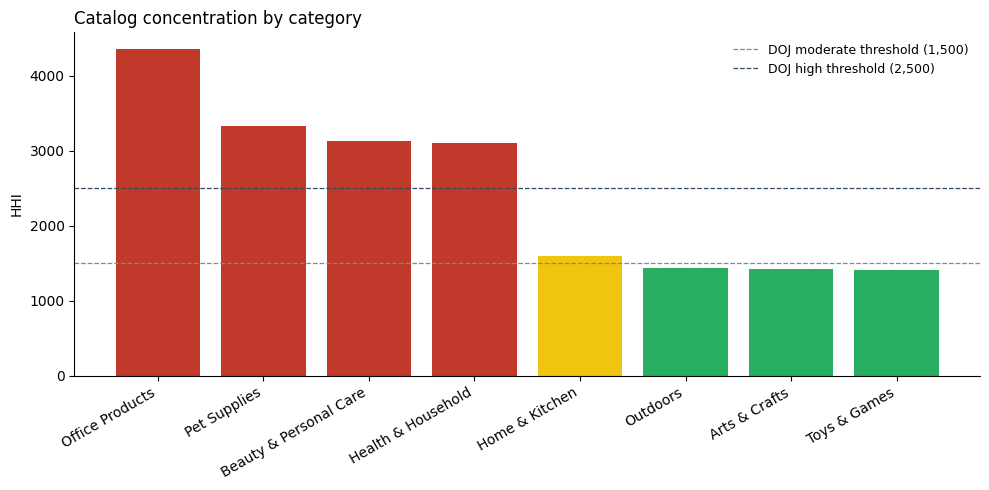

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
level_color = {'low': '#27ae60', 'moderate': '#f1c40f', 'high': '#c0392b'}
colors = [level_color[l] for l in summary['concentration_level']]
ax.bar(summary['category'], summary['hhi'], color=colors)
ax.axhline(1500, color='#7f8c8d', linestyle='--', linewidth=0.9, label='DOJ moderate threshold (1,500)')
ax.axhline(2500, color='#34495e', linestyle='--', linewidth=0.9, label='DOJ high threshold (2,500)')
ax.set_ylabel('HHI')
ax.set_title('Catalog concentration by category', loc='left')
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()


## What a counselor does next

* For each **high** category in the audit, ask the seller whether the dominant SKU has a backup listing, an alternate supplier, or a second-source manufacturer. If not, that's the next risk to address.
* For **moderate** categories, the action is documentation: make sure the seller knows which SKU is the keystone and has a plan if it goes down.
* **Low** categories are the goal state — note them in the report so the seller can see what 'healthy' looks like for their own catalog.